<a href="https://colab.research.google.com/github/mariyavinson/Amazon-Sales-EDA/blob/main/90s_song_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_recognition = pd.read_csv('/content/drive/MyDrive/analytics/recognition_by_generation.csv')
df_recognition


,index,artist,song,mean_millennial_recognition,mean_gen_z_recognition
0,0,2 Pac,California Love,0.517602,0.268378
1,1,2Pac,How Do U Want It,0.209632,0.062439
2,2,702,Where My Girls At?,0.553481,0.244176
3,3,Ace Of Base,All That She Wants,0.830967,0.540097
4,4,Ace Of Base,Don't Turn Around,0.623149,0.372787
...,...,...,...,...,...
339,339,Wilson Phillips,Release Me,0.127727,0.060286
340,340,Wilson Phillips,You're In Love,0.130290,0.060126
341,341,Wreckx-N-Effect,Rump Shaker,0.469101,0.148085
342,342,Xscape,Just Kickin' It,0.092154,0.052923


In [ ]:
df_time = pd.read_csv('/content/drive/MyDrive/analytics/time_series_90s.csv')
df_time

,index,artist,song,years_old_13,years_old_12,years_old_11,years_old_10,years_old_9,years_old_8,years_old_7,...,years_pre_birth_1,years_pre_birth_2,years_pre_birth_3,years_pre_birth_4,years_pre_birth_5,years_pre_birth_6,years_pre_birth_7,years_pre_birth_8,years_pre_birth_9,years_pre_birth_10
0,0,2 Pac,California Love,0.647859,0.540000,0.711864,0.435484,0.644444,0.594203,0.600000,...,0.371429,0.285714,0.151515,0.181818,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,2Pac,How Do U Want It,0.265027,0.226415,0.382353,0.296296,0.229730,0.283582,0.138889,...,0.069767,0.027027,0.166667,0.081081,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,702,Where My Girls At?,0.630772,0.614286,0.660377,0.415385,0.532258,0.375000,0.415094,...,0.205882,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,3,Ace Of Base,All That She Wants,0.962963,0.940000,0.976190,0.877193,0.954545,0.953846,1.000000,...,0.702128,0.545455,0.545455,0.523810,0.588235,0.485714,0.480000,0.000000,0.000000,0.000000
4,4,Ace Of Base,Don't Turn Around,0.899068,0.909091,0.826923,0.800000,0.756757,0.772727,0.666667,...,0.388889,0.418605,0.363636,0.323529,0.414634,0.218750,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,339,Wilson Phillips,Release Me,0.695963,0.783784,0.694444,0.490566,0.518519,0.192308,0.254237,...,0.070175,0.062500,0.045455,0.023810,0.019231,0.021739,0.000000,0.137931,0.066667,0.085714
340,340,Wilson Phillips,You're In Love,0.505111,0.500000,0.469388,0.351852,0.428571,0.283333,0.245283,...,0.000000,0.067797,0.056604,0.038462,0.039216,0.068966,0.000000,0.062500,0.130435,0.000000
341,341,Wreckx-N-Effect,Rump Shaker,0.776325,0.745098,0.790323,0.634615,0.716981,0.564103,0.688525,...,0.365385,0.285714,0.254902,0.218182,0.093750,0.076923,0.033333,0.227273,0.000000,0.000000
342,342,Xscape,Just Kickin' It,0.188492,0.161290,0.112903,0.184615,0.098361,0.065574,0.113208,...,0.063830,0.019231,0.066667,0.027027,0.050000,0.081081,0.068966,0.000000,0.000000,0.000000


In [ ]:
df_recognition.shape


(344, 5)

In [ ]:
df_time.shape

(344, 27)

Merging similar columns in both datasets:

In [ ]:
df = pd.merge(df_recognition, df_time, on=['artist', 'song'], how='inner')

In [ ]:
df

,index_x,artist,song,mean_millennial_recognition,mean_gen_z_recognition,index_y,years_old_13,years_old_12,years_old_11,years_old_10,...,years_pre_birth_1,years_pre_birth_2,years_pre_birth_3,years_pre_birth_4,years_pre_birth_5,years_pre_birth_6,years_pre_birth_7,years_pre_birth_8,years_pre_birth_9,years_pre_birth_10
0,0,2 Pac,California Love,0.517602,0.268378,0,0.647859,0.540000,0.711864,0.435484,...,0.371429,0.285714,0.151515,0.181818,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,2Pac,How Do U Want It,0.209632,0.062439,1,0.265027,0.226415,0.382353,0.296296,...,0.069767,0.027027,0.166667,0.081081,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,702,Where My Girls At?,0.553481,0.244176,2,0.630772,0.614286,0.660377,0.415385,...,0.205882,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,3,Ace Of Base,All That She Wants,0.830967,0.540097,3,0.962963,0.940000,0.976190,0.877193,...,0.702128,0.545455,0.545455,0.523810,0.588235,0.485714,0.480000,0.000000,0.000000,0.000000
4,4,Ace Of Base,Don't Turn Around,0.623149,0.372787,4,0.899068,0.909091,0.826923,0.800000,...,0.388889,0.418605,0.363636,0.323529,0.414634,0.218750,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,339,Wilson Phillips,Release Me,0.127727,0.060286,339,0.695963,0.783784,0.694444,0.490566,...,0.070175,0.062500,0.045455,0.023810,0.019231,0.021739,0.000000,0.137931,0.066667,0.085714
340,340,Wilson Phillips,You're In Love,0.130290,0.060126,340,0.505111,0.500000,0.469388,0.351852,...,0.000000,0.067797,0.056604,0.038462,0.039216,0.068966,0.000000,0.062500,0.130435,0.000000
341,341,Wreckx-N-Effect,Rump Shaker,0.469101,0.148085,341,0.776325,0.745098,0.790323,0.634615,...,0.365385,0.285714,0.254902,0.218182,0.093750,0.076923,0.033333,0.227273,0.000000,0.000000
342,342,Xscape,Just Kickin' It,0.092154,0.052923,342,0.188492,0.161290,0.112903,0.184615,...,0.063830,0.019231,0.066667,0.027027,0.050000,0.081081,0.068966,0.000000,0.000000,0.000000


In [ ]:
df.head()

,index_x,artist,song,mean_millennial_recognition,mean_gen_z_recognition,index_y,years_old_13,years_old_12,years_old_11,years_old_10,...,years_pre_birth_1,years_pre_birth_2,years_pre_birth_3,years_pre_birth_4,years_pre_birth_5,years_pre_birth_6,years_pre_birth_7,years_pre_birth_8,years_pre_birth_9,years_pre_birth_10
0,0,2 Pac,California Love,0.517602,0.268378,0,0.647859,0.540000,0.711864,0.435484,...,0.371429,0.285714,0.151515,0.181818,0.000000,0.000000,0.00,0.0,0.0,0.0
1,1,2Pac,How Do U Want It,0.209632,0.062439,1,0.265027,0.226415,0.382353,0.296296,...,0.069767,0.027027,0.166667,0.081081,0.000000,0.000000,0.00,0.0,0.0,0.0
2,2,702,Where My Girls At?,0.553481,0.244176,2,0.630772,0.614286,0.660377,0.415385,...,0.205882,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.0,0.0,0.0
3,3,Ace Of Base,All That She Wants,0.830967,0.540097,3,0.962963,0.940000,0.976190,0.877193,...,0.702128,0.545455,0.545455,0.523810,0.588235,0.485714,0.48,0.0,0.0,0.0
4,4,Ace Of Base,Don't Turn Around,0.623149,0.372787,4,0.899068,0.909091,0.826923,0.800000,...,0.388889,0.418605,0.363636,0.323529,0.414634,0.218750,0.00,0.0,0.0,0.0


In [ ]:
df.tail()

,index_x,artist,song,mean_millennial_recognition,mean_gen_z_recognition,index_y,years_old_13,years_old_12,years_old_11,years_old_10,...,years_pre_birth_1,years_pre_birth_2,years_pre_birth_3,years_pre_birth_4,years_pre_birth_5,years_pre_birth_6,years_pre_birth_7,years_pre_birth_8,years_pre_birth_9,years_pre_birth_10
339,339,Wilson Phillips,Release Me,0.127727,0.060286,339,0.695963,0.783784,0.694444,0.490566,...,0.070175,0.062500,0.045455,0.023810,0.019231,0.021739,0.000000,0.137931,0.066667,0.085714
340,340,Wilson Phillips,You're In Love,0.130290,0.060126,340,0.505111,0.500000,0.469388,0.351852,...,0.000000,0.067797,0.056604,0.038462,0.039216,0.068966,0.000000,0.062500,0.130435,0.000000
341,341,Wreckx-N-Effect,Rump Shaker,0.469101,0.148085,341,0.776325,0.745098,0.790323,0.634615,...,0.365385,0.285714,0.254902,0.218182,0.093750,0.076923,0.033333,0.227273,0.000000,0.000000
342,342,Xscape,Just Kickin' It,0.092154,0.052923,342,0.188492,0.161290,0.112903,0.184615,...,0.063830,0.019231,0.066667,0.027027,0.050000,0.081081,0.068966,0.000000,0.000000,0.000000
343,343,diVINYLS,I Touch Myself,0.356767,0.093943,343,0.709179,0.625000,0.583333,0.545455,...,0.160714,0.134615,0.166667,0.140000,0.177778,0.047619,0.071429,0.000000,0.130435,0.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   index_x                      344 non-null    int64  
 1   artist                       344 non-null    object 
 2   song                         344 non-null    object 
 3   mean_millennial_recognition  344 non-null    float64
 4   mean_gen_z_recognition       344 non-null    float64
 5   index_y                      344 non-null    int64  
 6   years_old_13                 344 non-null    float64
 7   years_old_12                 344 non-null    float64
 8   years_old_11                 344 non-null    float64
 9   years_old_10                 344 non-null    float64
 10  years_old_9                  344 non-null    float64
 11  years_old_8                  344 non-null    float64
 12  years_old_7                  344 non-null    float64
 13  years_old_6         

In [ ]:
df.describe()

,index_x,mean_millennial_recognition,mean_gen_z_recognition,index_y,years_old_13,years_old_12,years_old_11,years_old_10,years_old_9,years_old_8,...,years_pre_birth_1,years_pre_birth_2,years_pre_birth_3,years_pre_birth_4,years_pre_birth_5,years_pre_birth_6,years_pre_birth_7,years_pre_birth_8,years_pre_birth_9,years_pre_birth_10
count,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,...,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000,344.000000
mean,171.500000,0.401364,0.235506,171.500000,0.628447,0.598577,0.567753,0.524892,0.493182,0.457457,...,0.251575,0.209928,0.189620,0.159727,0.141217,0.116981,0.095605,0.078704,0.058703,0.027077
std,99.448479,0.265956,0.210541,99.448479,0.245944,0.251036,0.262154,0.266882,0.270655,0.274115,...,0.232168,0.214869,0.211834,0.199762,0.190924,0.173732,0.160761,0.146582,0.121197,0.083679
min,0.000000,0.043351,0.019483,0.000000,0.126577,0.046154,0.019231,0.015873,0.041667,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,85.750000,0.178364,0.095589,85.750000,0.437623,0.395196,0.349944,0.301415,0.264151,0.217803,...,0.085562,0.058403,0.036201,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,171.500000,0.344978,0.155398,171.500000,0.641834,0.621417,0.556466,0.520691,0.477592,0.407207,...,0.165423,0.136809,0.125000,0.087977,0.073171,0.047065,0.000000,0.000000,0.000000,0.000000
75%,257.250000,0.584260,0.303051,257.250000,0.840540,0.786114,0.790659,0.751179,0.712225,0.673456,...,0.339073,0.300327,0.273173,0.227504,0.187907,0.157895,0.121212,0.120303,0.076923,0.000000
max,343.000000,0.991851,0.963497,343.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.961538,0.962963,0.928571,0.900000,0.960000,0.933333,0.953488,0.830189,0.875000,0.851852


In [ ]:
df.isnull().sum()

,0
index_x,0
artist,0
song,0
mean_millennial_recognition,0
mean_gen_z_recognition,0
index_y,0
years_old_13,0
years_old_12,0
years_old_11,0
years_old_10,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Dropping unnecessary columns:

In [ ]:
df= df.drop(['index_x','index_y'],axis=1)

In [ ]:
df.head()

,artist,song,mean_millennial_recognition,mean_gen_z_recognition,years_old_13,years_old_12,years_old_11,years_old_10,years_old_9,years_old_8,...,years_pre_birth_1,years_pre_birth_2,years_pre_birth_3,years_pre_birth_4,years_pre_birth_5,years_pre_birth_6,years_pre_birth_7,years_pre_birth_8,years_pre_birth_9,years_pre_birth_10
0,2 Pac,California Love,0.517602,0.268378,0.647859,0.540000,0.711864,0.435484,0.644444,0.594203,...,0.371429,0.285714,0.151515,0.181818,0.000000,0.000000,0.00,0.0,0.0,0.0
1,2Pac,How Do U Want It,0.209632,0.062439,0.265027,0.226415,0.382353,0.296296,0.229730,0.283582,...,0.069767,0.027027,0.166667,0.081081,0.000000,0.000000,0.00,0.0,0.0,0.0
2,702,Where My Girls At?,0.553481,0.244176,0.630772,0.614286,0.660377,0.415385,0.532258,0.375000,...,0.205882,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.0,0.0,0.0
3,Ace Of Base,All That She Wants,0.830967,0.540097,0.962963,0.940000,0.976190,0.877193,0.954545,0.953846,...,0.702128,0.545455,0.545455,0.523810,0.588235,0.485714,0.48,0.0,0.0,0.0
4,Ace Of Base,Don't Turn Around,0.623149,0.372787,0.899068,0.909091,0.826923,0.800000,0.756757,0.772727,...,0.388889,0.418605,0.363636,0.323529,0.414634,0.218750,0.00,0.0,0.0,0.0


Checking datatypes:

In [ ]:
df.dtypes

,0
artist,object
song,object
mean_millennial_recognition,float64
mean_gen_z_recognition,float64
years_old_13,float64
years_old_12,float64
years_old_11,float64
years_old_10,float64
years_old_9,float64
years_old_8,float64


Converting Object columns:

In [ ]:
df['artist']=df['artist'].str.strip()

In [ ]:
df['song']=df['song'].str.strip()

In [ ]:
df['artist'].head(10)

,artist
0,2 Pac
1,2Pac
2,702
3,Ace Of Base
4,Ace Of Base
5,Ace Of Base
6,Adina Howard
7,Aerosmith
8,Aerosmith
9,Alanis Morissette


In [ ]:
df['artist'].nunique()

208

In [ ]:
df['song'].nunique()

342

In [ ]:
df['recognition_gap']=(df['mean_millennial_recognition']-df['mean_gen_z_recognition'])

In [ ]:
df[['artist','song','mean_millennial_recognition','mean_gen_z_recognition','recognition_gap']].head()

,artist,song,mean_millennial_recognition,mean_gen_z_recognition,recognition_gap
0,2 Pac,California Love,0.517602,0.268378,0.249224
1,2Pac,How Do U Want It,0.209632,0.062439,0.147192
2,702,Where My Girls At?,0.553481,0.244176,0.309305
3,Ace Of Base,All That She Wants,0.830967,0.540097,0.290870
4,Ace Of Base,Don't Turn Around,0.623149,0.372787,0.250362


In [ ]:
df['average_recognition']=(df['mean_millennial_recognition']+df['mean_gen_z_recognition'])/2

Most recognized songs among Millennials:

In [ ]:
df.sort_values('mean_millennial_recognition',ascending=False).head(10)

,artist,song,mean_millennial_recognition,mean_gen_z_recognition,years_old_13,years_old_12,years_old_11,years_old_10,years_old_9,years_old_8,...,years_pre_birth_3,years_pre_birth_4,years_pre_birth_5,years_pre_birth_6,years_pre_birth_7,years_pre_birth_8,years_pre_birth_9,years_pre_birth_10,recognition_gap,average_recognition
47,Britney Spears,..Baby One More Time,0.991851,0.961960,0.990476,0.984127,0.982759,1.000000,1.000000,0.969697,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.029891,0.976906
66,Cher,Believe,0.983381,0.899437,1.000000,1.000000,1.000000,0.964912,0.967213,1.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.083943,0.941409
290,"Spice Girls, The",Wannabe,0.983007,0.926500,0.995098,0.983051,1.000000,1.000000,0.984127,0.950820,...,0.880952,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.056507,0.954753
156,Lou Bega,Mambo No. 5,0.982905,0.919295,1.000000,0.984848,0.967213,0.935484,0.984127,1.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.063610,0.951100
62,Celine Dion,My Heart Will Go On,0.974674,0.963497,1.000000,0.986667,1.000000,0.986486,0.987500,0.981481,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.011178,0.969086
155,Los Del Rio,Macarena,0.974079,0.866160,0.968664,1.000000,1.000000,0.983607,0.936508,1.000000,...,0.857143,0.826087,0.0,0.0,0.0,0.0,0.0,0.0,0.107920,0.920120
21,"Backstreet Boys, The",Everybody,0.966933,0.857472,0.973869,1.000000,0.953846,0.958333,0.945455,0.967213,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.109461,0.912202
245,R. Kelly,I Believe I Can Fly,0.962350,0.819579,0.978495,0.983333,0.985507,0.962264,0.985294,0.921569,...,0.848485,0.821429,0.0,0.0,0.0,0.0,0.0,0.0,0.142771,0.890964
285,Smash Mouth,All Star,0.951832,0.923792,0.969597,1.000000,0.985507,0.942029,0.950000,0.953846,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.028040,0.937812
265,Santana,Smooth,0.930521,0.569471,0.984503,0.972222,0.957143,0.984127,0.879310,0.916667,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.361050,0.749996


Most recognized songs among Gen Z:

In [ ]:
df.sort_values('mean_gen_z_recognition',ascending=False).head(10)

,artist,song,mean_millennial_recognition,mean_gen_z_recognition,years_old_13,years_old_12,years_old_11,years_old_10,years_old_9,years_old_8,...,years_pre_birth_3,years_pre_birth_4,years_pre_birth_5,years_pre_birth_6,years_pre_birth_7,years_pre_birth_8,years_pre_birth_9,years_pre_birth_10,recognition_gap,average_recognition
62,Celine Dion,My Heart Will Go On,0.974674,0.963497,1.000000,0.986667,1.000000,0.986486,0.987500,0.981481,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.011178,0.969086
47,Britney Spears,..Baby One More Time,0.991851,0.961960,0.990476,0.984127,0.982759,1.000000,1.000000,0.969697,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.029891,0.976906
290,"Spice Girls, The",Wannabe,0.983007,0.926500,0.995098,0.983051,1.000000,1.000000,0.984127,0.950820,...,0.880952,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.056507,0.954753
285,Smash Mouth,All Star,0.951832,0.923792,0.969597,1.000000,0.985507,0.942029,0.950000,0.953846,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.028040,0.937812
156,Lou Bega,Mambo No. 5,0.982905,0.919295,1.000000,0.984848,0.967213,0.935484,0.984127,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.063610,0.951100
66,Cher,Believe,0.983381,0.899437,1.000000,1.000000,1.000000,0.964912,0.967213,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.083943,0.941409
286,Snap!,The Power,0.920342,0.883444,1.000000,0.979592,0.969697,0.933333,0.928571,0.980769,...,0.928571,0.900000,0.960000,0.933333,0.953488,0.685714,0.875,0.851852,0.036898,0.901893
155,Los Del Rio,Macarena,0.974079,0.866160,0.968664,1.000000,1.000000,0.983607,0.936508,1.000000,...,0.857143,0.826087,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.107920,0.920120
21,"Backstreet Boys, The",Everybody,0.966933,0.857472,0.973869,1.000000,0.953846,0.958333,0.945455,0.967213,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.109461,0.912202
331,Whitney Houston,I Will Always Love You,0.906714,0.852951,0.974150,0.973333,0.963636,0.980000,0.953271,0.913386,...,0.867470,0.862069,0.869565,0.852459,0.822581,0.830189,0.000,0.000000,0.053763,0.879832


Songs with biggest generational difference:

In [ ]:
df.sort_values('recognition_gap',ascending=False).head(10)

,artist,song,mean_millennial_recognition,mean_gen_z_recognition,years_old_13,years_old_12,years_old_11,years_old_10,years_old_9,years_old_8,...,years_pre_birth_3,years_pre_birth_4,years_pre_birth_5,years_pre_birth_6,years_pre_birth_7,years_pre_birth_8,years_pre_birth_9,years_pre_birth_10,recognition_gap,average_recognition
277,Shania Twain,You're Still The One,0.815294,0.302974,0.948482,0.870968,0.878788,0.830769,0.862069,0.761194,...,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.512320,0.559134
336,Will Smith,Wild Wild West,0.757088,0.280827,0.924473,0.827586,0.813559,0.833333,0.650000,0.612245,...,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.476261,0.518957
23,Barenaked Ladies,One Week,0.728785,0.256913,0.884207,0.714286,0.746479,0.741935,0.761905,0.737705,...,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.471872,0.492849
22,"Backstreet Boys, The",Quit Playing Games,0.756691,0.299312,0.898954,0.875000,0.875000,0.810811,0.666667,0.730159,...,0.266667,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.457379,0.528002
126,Jennifer Lopez,If You Had My Love,0.755161,0.303283,0.921203,0.892308,0.785714,0.773585,0.807018,0.621212,...,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.451878,0.529222
270,Savage Garden,Truly Madly Deeply,0.633496,0.195978,0.795698,0.777778,0.679612,0.583333,0.641509,0.530612,...,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.437518,0.414737
280,Sheryl Crow,All I Wanna Do,0.758426,0.329596,0.934521,0.933439,0.931529,0.924528,0.895894,0.877333,...,0.377586,0.367041,0.25567,0.246296,0.0,0.0,0.0,0.0,0.428830,0.544011
139,K-Ci and JoJo,All My Life,0.618631,0.191354,0.754644,0.732143,0.706667,0.546875,0.714286,0.633333,...,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.427277,0.404993
269,Savage Garden,I Want You,0.559081,0.137610,0.724764,0.764706,0.615385,0.613333,0.711538,0.381818,...,0.114286,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.421471,0.348345
268,Savage Garden,I Knew I Loved You,0.715086,0.301116,0.824753,0.706667,0.768116,0.685714,0.685185,0.629630,...,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.413970,0.508101


Songs with millennial recognition above 80%:

In [ ]:
high_millennial = df[df['mean_millennial_recognition']> 0.80]
high_millennial.head()

,artist,song,mean_millennial_recognition,mean_gen_z_recognition,years_old_13,years_old_12,years_old_11,years_old_10,years_old_9,years_old_8,...,years_pre_birth_3,years_pre_birth_4,years_pre_birth_5,years_pre_birth_6,years_pre_birth_7,years_pre_birth_8,years_pre_birth_9,years_pre_birth_10,recognition_gap,average_recognition
3,Ace Of Base,All That She Wants,0.830967,0.540097,0.962963,0.940000,0.976190,0.877193,0.954545,0.953846,...,0.545455,0.523810,0.588235,0.485714,0.48,0.0,0.0,0.0,0.290870,0.685532
5,Ace Of Base,The Sign,0.879769,0.597304,0.978571,0.954545,0.983607,0.933333,0.929825,0.907692,...,0.634615,0.583333,0.735294,0.472222,0.00,0.0,0.0,0.0,0.282465,0.738537
7,Aerosmith,I Don't Want To Miss A Thing,0.908949,0.665521,0.959235,0.953125,0.966102,0.986667,0.870370,0.930556,...,0.000000,0.000000,0.000000,0.000000,0.00,0.0,0.0,0.0,0.243427,0.787235
9,Alanis Morissette,Ironic,0.887612,0.587672,0.969664,0.978723,0.985507,0.950000,0.926471,0.936508,...,0.607143,0.457143,0.000000,0.000000,0.00,0.0,0.0,0.0,0.299940,0.737642
21,"Backstreet Boys, The",Everybody,0.966933,0.857472,0.973869,1.000000,0.953846,0.958333,0.945455,0.967213,...,0.000000,0.000000,0.000000,0.000000,0.00,0.0,0.0,0.0,0.109461,0.912202


Song recognition in Gen Z above 80%:

In [ ]:
high_gen_z = df[df['mean_gen_z_recognition']> 0.80]
high_gen_z.head()

,artist,song,mean_millennial_recognition,mean_gen_z_recognition,years_old_13,years_old_12,years_old_11,years_old_10,years_old_9,years_old_8,...,years_pre_birth_3,years_pre_birth_4,years_pre_birth_5,years_pre_birth_6,years_pre_birth_7,years_pre_birth_8,years_pre_birth_9,years_pre_birth_10,recognition_gap,average_recognition
21,"Backstreet Boys, The",Everybody,0.966933,0.857472,0.973869,1.000000,0.953846,0.958333,0.945455,0.967213,...,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.109461,0.912202
47,Britney Spears,..Baby One More Time,0.991851,0.961960,0.990476,0.984127,0.982759,1.000000,1.000000,0.969697,...,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.029891,0.976906
62,Celine Dion,My Heart Will Go On,0.974674,0.963497,1.000000,0.986667,1.000000,0.986486,0.987500,0.981481,...,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.011178,0.969086
66,Cher,Believe,0.983381,0.899437,1.000000,1.000000,1.000000,0.964912,0.967213,1.000000,...,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.083943,0.941409
72,Coolio,Gangsta's Paradise,0.923186,0.818843,0.987951,0.960526,0.989691,0.973684,0.969697,0.974684,...,0.8,0.866667,0.78125,0.0,0.0,0.0,0.0,0.0,0.104343,0.871015


In [ ]:
df.loc[0:5,['artist','song','mean_millennial_recognition']]

,artist,song,mean_millennial_recognition
0,2 Pac,California Love,0.517602
1,2Pac,How Do U Want It,0.209632
2,702,Where My Girls At?,0.553481
3,Ace Of Base,All That She Wants,0.830967
4,Ace Of Base,Don't Turn Around,0.623149
5,Ace Of Base,The Sign,0.879769


In [ ]:
df.iloc[0:5,0:3]

,artist,song,mean_millennial_recognition
0,2 Pac,California Love,0.517602
1,2Pac,How Do U Want It,0.209632
2,702,Where My Girls At?,0.553481
3,Ace Of Base,All That She Wants,0.830967
4,Ace Of Base,Don't Turn Around,0.623149


In [ ]:
df['artist'].value_counts().head(10)

,count
artist,
Mariah Carey,18
Janet Jackson,11
Whitney Houston,9
Boyz II Men,8
Madonna,8
Celine Dion,7
TLC,6
R. Kelly,5
Monica,4


In [ ]:
artist_recognition = df.groupby('artist')[['mean_millennial_recognition','mean_gen_z_recognition']].mean()

In [ ]:
artist_recognition.head()

,mean_millennial_recognition,mean_gen_z_recognition
artist,,
2 Pac,0.517602,0.268378
2Pac,0.209632,0.062439
702,0.553481,0.244176
Ace Of Base,0.777962,0.503396
Adina Howard,0.207478,0.139892


In [ ]:
artist_recognition.sort_values('mean_millennial_recognition',ascending=False).head(10)

,mean_millennial_recognition,mean_gen_z_recognition
artist,,
Britney Spears,0.991851,0.961960
Cher,0.983381,0.899437
"Spice Girls, The",0.983007,0.926500
Lou Bega,0.982905,0.919295
Los Del Rio,0.974079,0.866160
Smash Mouth,0.951832,0.923792
Santana,0.930521,0.569471
Christina Aguilera,0.922637,0.694316
Snap!,0.920342,0.883444


DATA VISUALISATIONS:

1. Top songs among Millennials

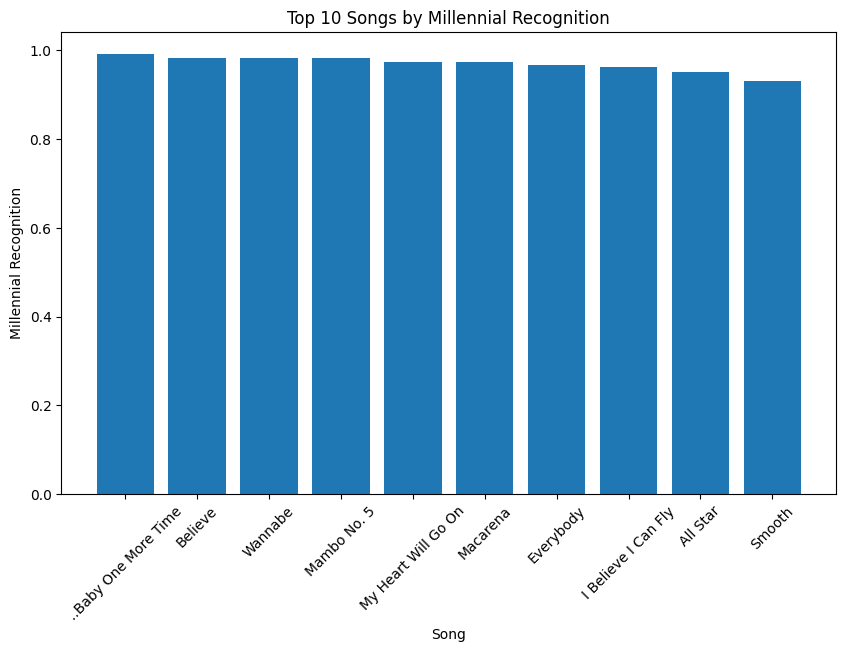

In [ ]:
top_millennials = df.sort_values('mean_millennial_recognition',ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.bar(top_millennials['song'],top_millennials['mean_millennial_recognition'])
plt.xticks(rotation=45)
plt.xlabel('Song')
plt.ylabel('Millennial Recognition')
plt.title('Top 10 Songs by Millennial Recognition')

plt.show()

2. Top songs among Gen Z

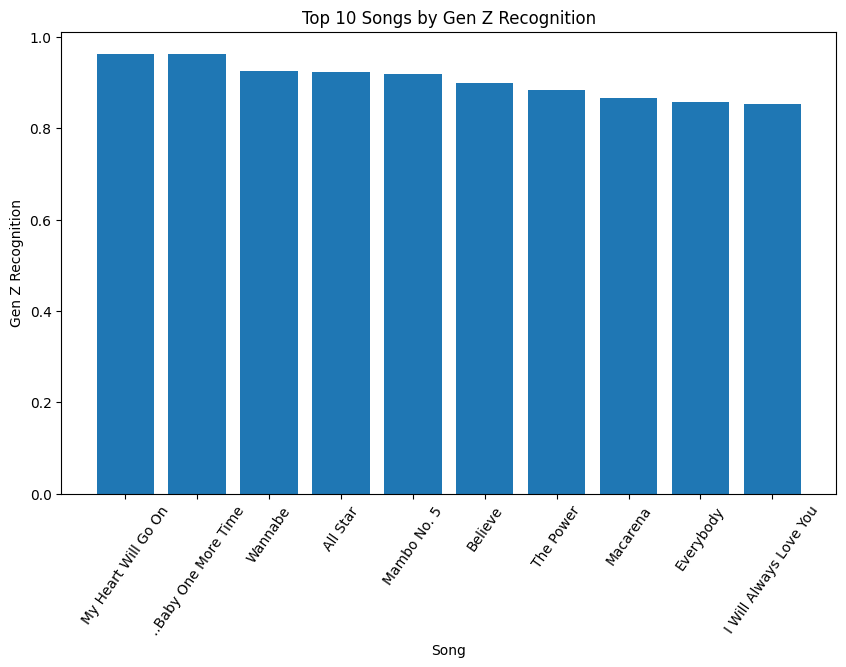

In [ ]:
top_genz = df.sort_values('mean_gen_z_recognition',ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.bar(top_genz['song'],top_genz['mean_gen_z_recognition'])

plt.xticks(rotation=55)
plt.xlabel('Song')
plt.ylabel('Gen Z Recognition')
plt.title('Top 10 Songs by Gen Z Recognition')

plt.show()

3. Distribution of Millennial recognition

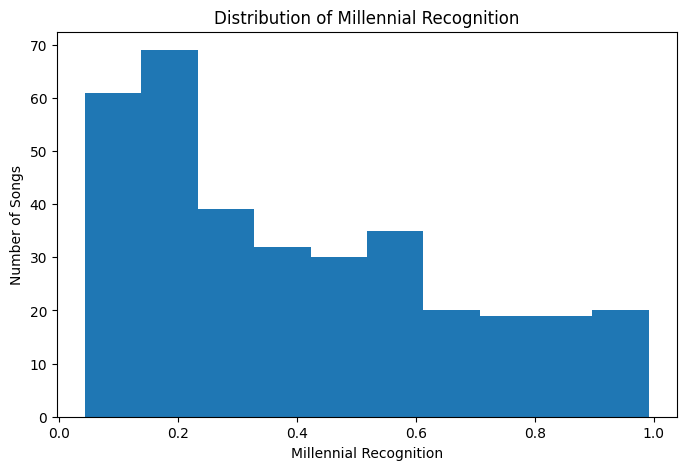

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['mean_millennial_recognition'],
    bins=10
)

plt.xlabel('Millennial Recognition')
plt.ylabel('Number of Songs')
plt.title('Distribution of Millennial Recognition')

plt.show()

4. Generation-to-generation comparison

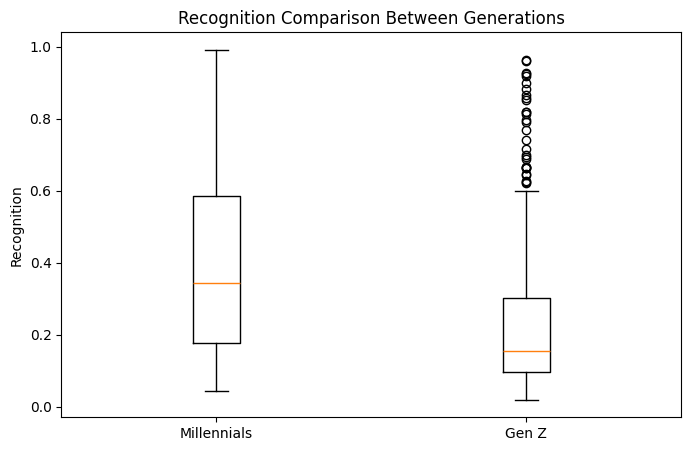

In [ ]:
plt.figure(figsize=(8, 5))

plt.boxplot([df['mean_millennial_recognition'],df['mean_gen_z_recognition']])

plt.xticks([1, 2],['Millennials', 'Gen Z'])

plt.ylabel('Recognition')
plt.title('Recognition Comparison Between Generations')

plt.show()

5. Millennial vs Gen Z

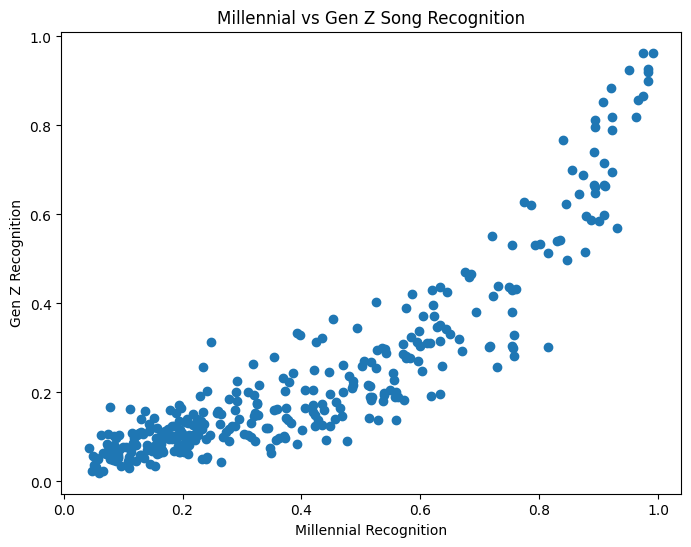

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['mean_millennial_recognition'],
    df['mean_gen_z_recognition']
)

plt.xlabel('Millennial Recognition')
plt.ylabel('Gen Z Recognition')
plt.title('Millennial vs Gen Z Song Recognition')

plt.show()

6. Distribution Gen Z recognition

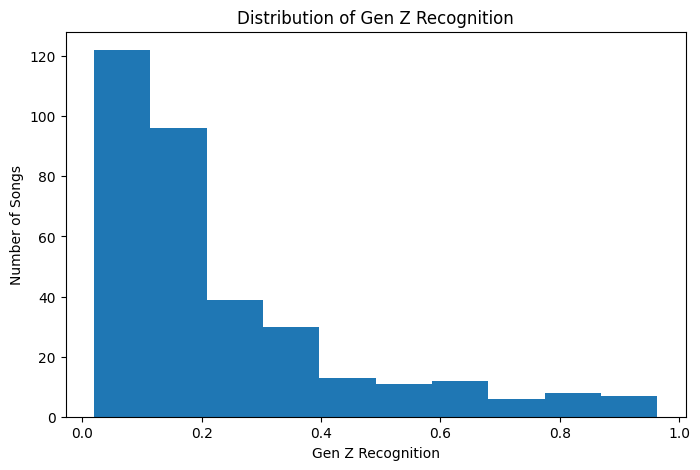

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df['mean_gen_z_recognition'],bins=10)

plt.xlabel('Gen Z Recognition')
plt.ylabel('Number of Songs')
plt.title('Distribution of Gen Z Recognition')

plt.show()

7. Distribution of Millennial recognition

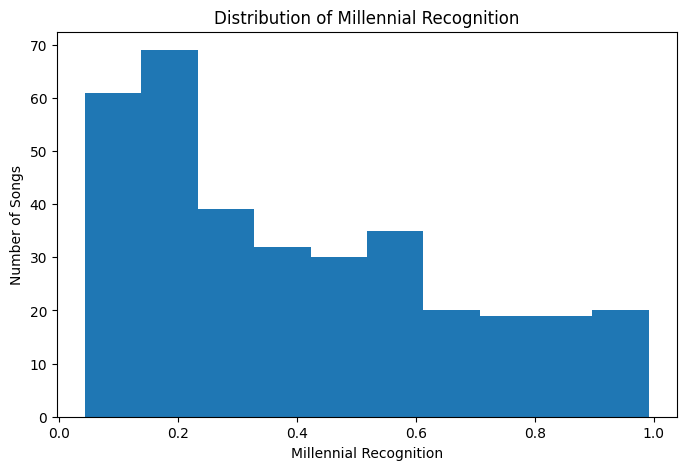

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df['mean_millennial_recognition'],bins=10)

plt.xlabel('Millennial Recognition')
plt.ylabel('Number of Songs')
plt.title('Distribution of Millennial Recognition')

plt.show()

9. Top 10 songs with biggest generational gaps

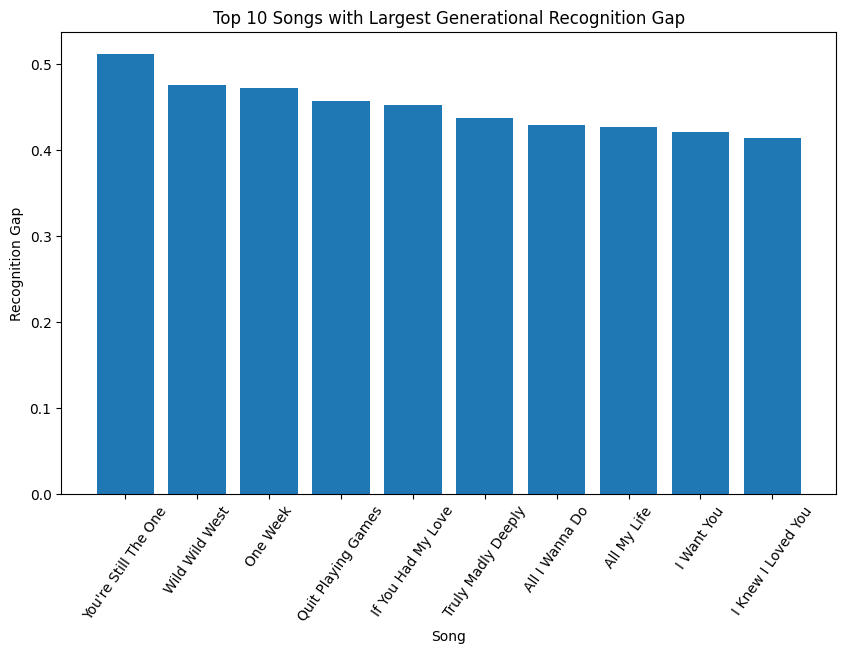

In [ ]:
top_gap = df.sort_values('recognition_gap',ascending=False).head(10)

plt.figure(figsize=(10, 6))

plt.bar(top_gap['song'],top_gap['recognition_gap'])

plt.xticks(rotation=55)
plt.xlabel('Song')
plt.ylabel('Recognition Gap')
plt.title('Top 10 Songs with Largest Generational Recognition Gap')

plt.show()

10. Recognition categories

In [ ]:
df['recognition_category'] = pd.cut(
    df['average_recognition'],
    bins=[0, 0.25, 0.50, 0.75, 1],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

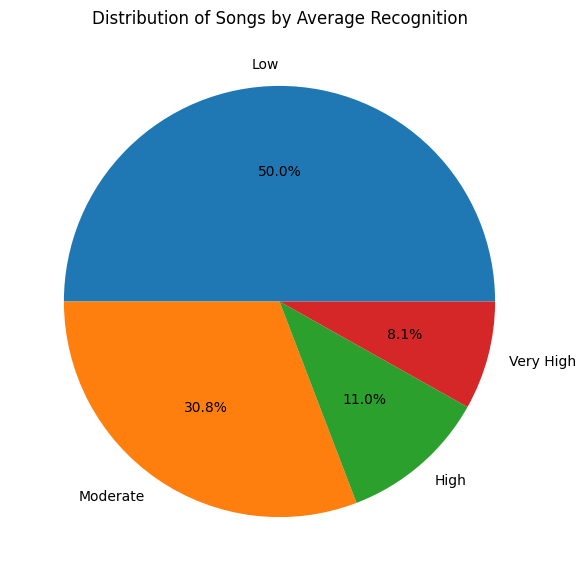

In [ ]:
category_counts = df['recognition_category'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Songs by Average Recognition')

plt.show()

The pie chart shows the distribution of 90s songs across different average recognition levels among Millennials and Gen Z. The songs are categorized as Low, Moderate, High, and Very High based on their average recognition score.

11. Trends across the time/age variables

In [ ]:
year_columns = [col for col in df.columns if col.startswith('years_')]
year_means = df[year_columns].mean()

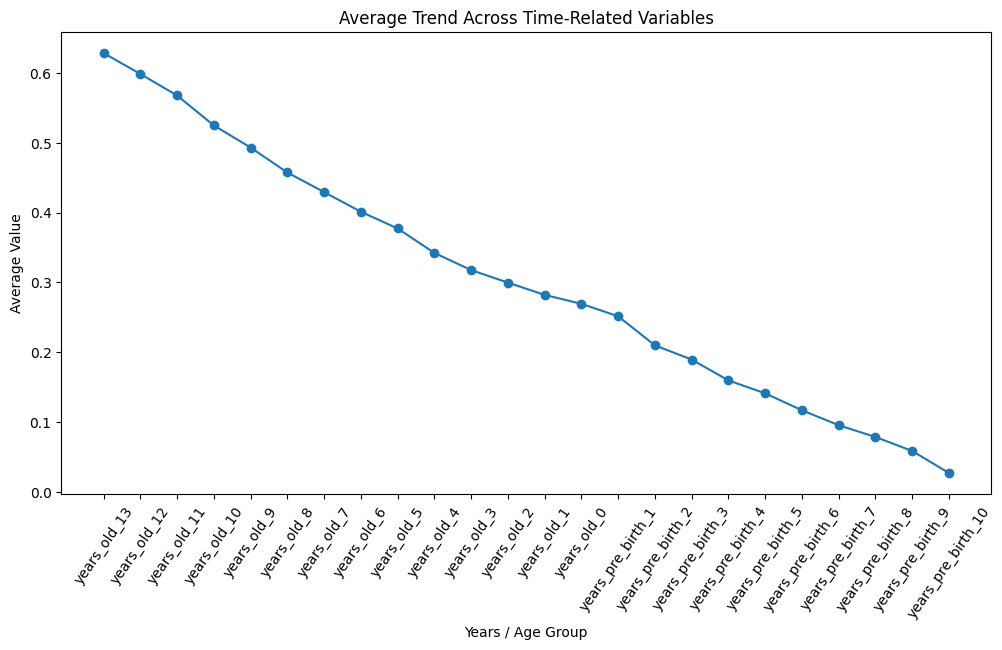

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(year_means.index,year_means.values,marker='o')

plt.xticks(rotation=55)
plt.xlabel('Years / Age Group')
plt.ylabel('Average Value')
plt.title('Average Trend Across Time-Related Variables')

plt.show()